# Re-checking earlier logic-metric results across label sets — demo

**Research context.** We want *gold-free* metrics that score whether a candidate first-order-logic (FOL) formalization is
faithful to its natural-language sentence (NL→FOL). Iteration 1 built several candidate metrics and baselines on the
FOLIO-dev *screen* (Logic-LM outputs of gpt-3.5 / gpt-4 / davinci-003):

| metric | what it is |
|---|---|
| `fused_H` (`p_fused_H`) | exp A FOL-Triage fused score (L1 smells + L2 bag-of-words anchoring + L3) |
| `L2_bow` (`bow_uncarried`) | content words of the sentence not carried into the formula |
| `L3` (`l3_score`) | exp A layer-3 score |
| `c_score` | exp C consensus score: disagreement of the candidate with peer formalizations of the same sentence |
| `judge_cheap_disg` | exp D cheap LLM-as-judge with a *disguised* prompt — the **reference baseline** every metric is compared against |
| `PT` (`PT_oof`) | "PEER+TEXT": cross-fitted logistic regression on `c_score + bow_uncarried + l3_score` |

Each item carries **several labels**: the solver labels of exps A, C and D (prover-checked equivalence to the FOLIO gold)
and the adjudicated label of dataset E (tiers A/B/auto_only). They disagree, mostly because many gold formulas are wrong
or have a different granularity. `eval.py` is a **zero-LLM-spend, CPU-only re-analysis**. It declares every *label regime*,
builds a **same-item common set** per regime, and reports AUROC with sentence-cluster bootstrap CIs, the Δ against the judge,
the pre-registered rule verdicts, the cross-fitted PEER+TEXT preview, and the **label-only shift** (same items, different labels).

**What this demo runs.** The full script joins raw iteration-1 files that are not shipped with this repo. This notebook
instead rebuilds the per-item master frame from `mini_demo_data.json`: **100 track-L items** from `eval_out.json`, all of them
in both the solver-consensus (`R_SOLVER_CONS`) and the adjudicated tier-A/B (`R_ADJ_AB`) common sets. Every one of the
36 items whose solver and adjudicated labels disagree is kept. The notebook then runs steps 3–6 of `eval.py`
(regimes → PEER+TEXT cross-fitting → common-item tables and rule verdicts → regime shift and flipped-item diagnostic) with
the original code. Steps 0–2 (hashing and re-derivation against the raw audit files), step 7 (P1/P2, which needs per-item repair
operators) and steps 8–13 (audit add-ons) need raw inputs that are not in the demo data, so they are skipped.

> With 100 items, no regime passes the testability rule (≥50 ERROR and ≥50 CORRECT). The numbers show how the method works
> and where effects point. They are not the paper's estimates, which are printed next to them for comparison at the end.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scikit-learn, scipy, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0')

## Imports
The import block of `eval.py`, followed by the imports of the `src/` modules (`stats_utils`, `steps_core`, `steps_models`)
whose functions are inlined below. `matplotlib` is added for the final figure.

In [2]:
# ---- eval.py
import argparse
import gc
import json
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from loguru import logger

# ---- src/stats_utils.py, src/steps_core.py, src/steps_models.py
import hashlib
import itertools
import math
import random
import re
from collections import Counter

from scipy import stats
from scipy import stats as sps
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score

# ---- notebook additions
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

## Data loading helper
The demo data is fetched from GitHub; if that fails, the notebook falls back to a local `mini_demo_data.json`.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_qck1d05BqxkX/round-2/evaluation-1/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
examples = data["datasets"][0]["examples"]
print(data["metadata"]["source"])
print(data["metadata"]["selection"])
print(f"{len(examples)} examples; first one:")
print(json.dumps({k: v for k, v in examples[0].items() if not k.startswith("eval_")}, indent=1)[:1500])

full_eval_out.json -> datasets[0] 'folio_dev_logiclm_screen_trackL_trackH' (1,380 items)
100 of the 161 track-L items that sit in BOTH the R_SOLVER_CONS and R_ADJ_AB common sets; all solver/adjudicator label-flipped items kept, the rest sampled with random.Random(0) proportionally per label pair
100 examples; first one:
{
 "input": "{\"text\": \"Montana is home to the city of Missoula.\", \"candidate_fol\": \"In(missoula, montana)\"}",
 "output": "{\"R_SOLVER_CONS\": \"ERROR\", \"R_SOLVER_OWN_A\": \"ERROR\", \"R_SOLVER_OWN_C\": \"ERROR\", \"R_SOLVER_OWN_D\": \"ERROR\", \"R_ADJ_AB\": \"ERROR\", \"R_ADJ_A\": \"ERROR\", \"R_ADJ_ALL\": \"ERROR\", \"R_ADJ_AB_CONT_C\": \"ERROR\", \"R_ADJ_AB_CONT_E\": \"ERROR\", \"L_UNPARSEABLE_AS_ERROR\": \"ERROR\", \"H_SOLVER\": \"not_in_regime\", \"H_ADJ_AB\": \"not_in_regime\", \"H_CURATOR\": \"not_in_regime\", \"_raw\": {\"lab_A\": \"ERROR\", \"lab_C\": \"ERROR\", \"lab_D\": \"ERROR\", \"E_final_label\": \"ERROR\", \"E_label_tier\": \"A\"}}",
 "metadata_

## Config
`eval.py` has two modes: the full run (`B=2000` bootstrap resamples, 5 fold seeds, 500 Kendall-τ resamples) and `--quick`
(200 / 1 / 100). All three are exposed here. A few inner bootstraps inside the original functions are hard-coded at 2000
(step 5 label-only shift, step 6 PEER+TEXT deltas). They are left unchanged because they are cheap on 100 items.

In [5]:
B = 2000          # cluster-bootstrap resamples for the common-item tables (original full run: 2000; --quick: 200)
n_seeds = 5     # cross-fitting fold seeds for the PEER+TEXT models (original: 5; --quick: 1)
B_TAU = 500      # sentence resamples for the Kendall-tau CI of metric rankings (original: 500; --quick: 100)

## Setup from `eval.py`: output folder, logging, CSV writer, JSON sanitiser
Copied from `eval.py`. The only change: `WS` (originally the script's folder) points to a local `eval_demo_outputs/` folder,
and the file log sink is dropped (stdout only). `out_tab` writes every table as a CSV whose first line names its source.

In [6]:
WS = Path("eval_demo_outputs")  # original: Path(__file__).resolve().parent
TAB = WS / "tables"
for d in (WS, TAB):
    d.mkdir(exist_ok=True)

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

# all-NaN feature columns inside a CV fold and single-class bootstrap resamples raise RuntimeWarnings that the code
# already handles (mean -> 0, resample -> NaN and counted as skipped)
warnings.filterwarnings("ignore", category=RuntimeWarning)

SOURCES = {}


def out_tab(t: pd.DataFrame, name: str, src: str) -> None:
    """Write a CSV whose first line is a comment naming its source files."""
    p = TAB / name
    with open(p, "w") as f:
        f.write(f"# source: {src}\n")
        t.to_csv(f, index=False)
    SOURCES[name] = src
    logger.debug(f"wrote {p} ({len(t)} rows)")


def jsafe(o):
    """Recursively convert numpy/pandas objects and NaN to JSON-safe values."""
    if isinstance(o, dict):
        return {str(k): jsafe(v) for k, v in o.items()}
    if isinstance(o, (list, tuple, set)):
        return [jsafe(v) for v in o]
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating, float)):
        return None if (np.isnan(o) or np.isinf(o)) else float(o)
    if isinstance(o, np.bool_):
        return bool(o)
    if isinstance(o, np.ndarray):
        return jsafe(o.tolist())
    if isinstance(o, pd.DataFrame):
        return jsafe(o.to_dict(orient="records"))
    if isinstance(o, pd.Series):
        return jsafe(o.to_dict())
    return o

# eval.py imports src/ as modules (`su`, `sc`, `sm`); here their code lives in this notebook's namespace
su = sc = sm = sys.modules["__main__"]

## Statistics primitives (`src/stats_utils.py`, verbatim)
Every score is **oriented so that higher = more likely ERROR**; labels are y=1 ERROR, y=0 CORRECT.
* `auroc`: the Mann-Whitney statistic, with ties counted 0.5.
* `ClusterBoot` / `boot_auc_w`: a **sentence-cluster bootstrap**. Whole sentences (cluster = `norm(text)`) are resampled with
  replacement, and every resample's AUROC is computed in one vectorised weighted step. Several candidate formalizations of
  the same sentence are therefore not treated as independent.
* `delong_paired` / `delong_clustered_paired`: paired AUROC-difference tests (plain and Obuchowski-clustered).
* `matched_fa_rule` / `flag_prob`: a randomised threshold that hits an exact false-alarm rate. Used to compare recall at a
  matched false-alarm (FA) rate.

In [7]:
B_RESAMPLES = 2000
SEED = 0

# exp D src/common.py::norm (gen_art_experiment_4/src/common.py lines 23-29), copied verbatim
_QUOTES = str.maketrans({"‘": "'", "’": "'", "“": '"', "”": '"', "–": "-", "—": "-", "−": "-"})


def norm(s: str) -> str:
    """Exp D's GroupKFold / bootstrap cluster key: lower-case, quotes unified, punctuation -> space, spaces collapsed."""
    s = (s or "").translate(_QUOTES).lower()
    s = re.sub(r"[^\w\s]", " ", s)
    return re.sub(r"\s+", " ", s).strip()


# exp C src/common.py line 23 (COARSE) and lines 48-52 (op_class), copied verbatim
COARSE = {"ADD": "COVERAGE", "DROP": "COVERAGE", "NEG": "POLARITY", "REV": "POLARITY", "QUANT": "POLARITY"}


def op_class(ops: list[str]) -> str:
    """Exp C's coarse operator class of a repair set: POLARITY / COVERAGE / STRUCT / MIXED (NONE if empty)."""
    if not ops:
        return "NONE"
    cs = {COARSE.get(o, "STRUCT") for o in ops}
    return cs.pop() if len(cs) == 1 else "MIXED"


# ----------------------------------------------------------------------------------------------- point statistics
def auroc(y: np.ndarray, s: np.ndarray) -> float:
    y = np.asarray(y)
    if len(np.unique(y)) < 2:
        return float("nan")
    return float(roc_auc_score(y, s))


def auprc(y: np.ndarray, s: np.ndarray) -> float:
    if len(np.unique(y)) < 2:
        return float("nan")
    return float(average_precision_score(y, s))


def tie_fraction(y: np.ndarray, s: np.ndarray) -> float:
    """Share of (ERROR, CORRECT) pairs whose scores are tied (Deutsch et al. 2023 'Ties Matter')."""
    pos, neg = s[y == 1], s[y == 0]
    if len(pos) == 0 or len(neg) == 0:
        return float("nan")
    cp, cn = Counter(np.round(pos, 9).tolist()), Counter(np.round(neg, 9).tolist())
    return sum(cp[v] * cn.get(v, 0) for v in cp) / (len(pos) * len(neg))


def ppv_at_prevalence(tpr: float | None, fpr: float | None, pi: float) -> float | None:
    """PPV = TPR*pi / (TPR*pi + FPR*(1-pi))."""
    if tpr is None or fpr is None:
        return None
    den = tpr * pi + fpr * (1 - pi)
    return None if den == 0 else tpr * pi / den


def at_flag(y: np.ndarray, flag: np.ndarray) -> dict:
    f = flag.astype(bool)
    P, N = int((y == 1).sum()), int((y == 0).sum())
    tp, fp = int((f & (y == 1)).sum()), int((f & (y == 0)).sum())
    rec = tp / P if P else None
    fa = fp / N if N else None
    return {"precision": (tp / (tp + fp)) if (tp + fp) else None, "recall": rec, "fa": fa,
            "prec_at_prev10": ppv_at_prevalence(rec, fa, 0.10), "prec_at_prev25": ppv_at_prevalence(rec, fa, 0.25),
            "n_flagged": int(f.sum())}


def wilson(k: float, n: float, z: float = 1.959964) -> tuple[float, float]:
    if n <= 0:
        return (float("nan"), float("nan"))
    p = k / n
    den = 1 + z * z / n
    c = (p + z * z / (2 * n)) / den
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return (max(0.0, c - h), min(1.0, c + h))


# ----------------------------------------------------------------------------------------------- cluster bootstrap
class ClusterBoot:
    """Sentence-cluster bootstrap weights: W[b, c] = multiplicity of cluster c in resample b (exp D convention)."""

    def __init__(self, clusters: list[str], B: int = B_RESAMPLES, seed: int = SEED):
        self.uc = sorted(set(clusters))
        idx = {c: i for i, c in enumerate(self.uc)}
        self.cid = np.array([idx[c] for c in clusters])
        rng = np.random.default_rng(seed)
        draws = rng.integers(0, len(self.uc), size=(B, len(self.uc)))
        self.W = np.zeros((B, len(self.uc)), dtype=np.float64)
        for b in range(B):
            np.add.at(self.W[b], draws[b], 1)
        self.B = B

    def item_W(self, mask: np.ndarray | None = None) -> np.ndarray:
        """B x n item weight matrix (optionally restricted to items in mask)."""
        cid = self.cid if mask is None else self.cid[mask]
        return self.W[:, cid]


def boot_auc_w(y: np.ndarray, s: np.ndarray, Wi: np.ndarray) -> np.ndarray:
    """Vectorised weighted AUROC (ties 0.5) for every row of the B x n weight matrix Wi. NaN where a class is empty."""
    u, inv = np.unique(s, return_inverse=True)
    K = len(u)
    onehot = np.zeros((len(s), K))
    onehot[np.arange(len(s)), inv] = 1.0
    P = Wi[:, y == 1] @ onehot[y == 1]
    N = Wi[:, y == 0] @ onehot[y == 0]
    cumN_before = np.cumsum(N, axis=1) - N
    num = (P * (cumN_before + 0.5 * N)).sum(1)
    den = P.sum(1) * N.sum(1)
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.where(den > 0, num / den, np.nan)


def ci95(a: np.ndarray) -> list:
    a = np.asarray(a, dtype=float)
    a = a[~np.isnan(a)]
    if len(a) == 0:
        return [None, None]
    return [float(np.percentile(a, 2.5)), float(np.percentile(a, 97.5))]


def boot_p_two_sided(d: np.ndarray) -> float:
    """Two-sided bootstrap p = 2 x min(share of Delta <= 0, share of Delta >= 0), capped at 1."""
    d = d[~np.isnan(d)]
    if len(d) == 0:
        return float("nan")
    return float(min(1.0, 2 * min(np.mean(d <= 0), np.mean(d >= 0))))


# ----------------------------------------------------------------------------------------------- DeLong
def _midrank(x: np.ndarray) -> np.ndarray:
    J = np.argsort(x, kind="mergesort")
    Z = x[J]
    N = len(x)
    T = np.zeros(N)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    out = np.empty(N)
    out[J] = T
    return out


def placements(y: np.ndarray, s: np.ndarray) -> tuple[float, np.ndarray, np.ndarray]:
    """Fast DeLong (Sun & Xu 2014) placement values: V10 per ERROR item (share of CORRECT below, ties 0.5) and
    V01 per CORRECT item (share of ERROR above, ties 0.5). AUROC = mean(V10) = mean(V01)."""
    pos, neg = s[y == 1], s[y == 0]
    m, n = len(pos), len(neg)
    tx, ty, tz = _midrank(pos), _midrank(neg), _midrank(np.concatenate([pos, neg]))
    v10 = (tz[:m] - tx) / n
    v01 = 1.0 - (tz[m:] - ty) / m
    return float(v10.mean()), v10, v01


def delong_paired(y: np.ndarray, s1: np.ndarray, s2: np.ndarray) -> dict:
    a1, v10a, v01a = placements(y, s1)
    a2, v10b, v01b = placements(y, s2)
    m, n = len(v10a), len(v01a)
    s10 = np.cov(np.vstack([v10a, v10b]))
    s01 = np.cov(np.vstack([v01a, v01b]))
    S = s10 / m + s01 / n
    var = S[0, 0] + S[1, 1] - 2 * S[0, 1]
    if var <= 0:
        return {"auc1": a1, "auc2": a2, "z": 0.0, "p": 1.0}
    z = (a1 - a2) / math.sqrt(var)
    return {"auc1": a1, "auc2": a2, "z": float(z), "p": float(2 * stats.norm.sf(abs(z)))}


def delong_clustered_paired(y: np.ndarray, s1: np.ndarray, s2: np.ndarray, clusters: np.ndarray) -> dict:
    """Obuchowski (1997) clustered-ROC variance for the paired AUROC difference: placement values are summed within
    sentence clusters and the variance is estimated from between-cluster variation of those sums."""
    a1, v10a, v01a = placements(y, s1)
    a2, v10b, v01b = placements(y, s2)
    d10, d01 = v10a - v10b, v01a - v01b
    ad = a1 - a2
    cp, cn = clusters[y == 1], clusters[y == 0]
    uc = sorted(set(clusters.tolist()))
    K = len(uc)
    M, N = len(d10), len(d01)
    idx = {c: i for i, c in enumerate(uc)}
    X, Y, mi, ni = np.zeros(K), np.zeros(K), np.zeros(K), np.zeros(K)
    np.add.at(X, [idx[c] for c in cp], d10)
    np.add.at(mi, [idx[c] for c in cp], 1)
    np.add.at(Y, [idx[c] for c in cn], d01)
    np.add.at(ni, [idx[c] for c in cn], 1)
    f = K / (K - 1)
    S10 = f / M * np.sum((X - mi * ad) ** 2)
    S01 = f / N * np.sum((Y - ni * ad) ** 2)
    S11 = f * np.sum((X - mi * ad) * (Y - ni * ad))
    var = S10 / M + S01 / N + 2 * S11 / (M * N)
    if var <= 0:
        return {"z": 0.0, "p": 1.0, "se": 0.0}
    z = ad / math.sqrt(var)
    return {"z": float(z), "p": float(2 * stats.norm.sf(abs(z))), "se": float(math.sqrt(var))}


def holm(pvals: dict) -> dict:
    items = [(k, v) for k, v in pvals.items() if v is not None and not (isinstance(v, float) and math.isnan(v))]
    items.sort(key=lambda kv: kv[1])
    m = len(items)
    out, run = {}, 0.0
    for i, (k, p) in enumerate(items):
        run = max(run, min(1.0, (m - i) * p))
        out[k] = run
    return out


# ----------------------------------------------------------------------------------------------- matched-FA operating point
def matched_fa_rule(s_correct: np.ndarray, f: float) -> tuple[float, float, float]:
    """Randomised threshold achieving FA exactly f on the CORRECT scores (= linear interpolation between adjacent ROC
    vertices). Returns (v, q, achieved_fa): an item is flagged with prob 1 if s > v, prob q if s == v, else 0."""
    sc = np.sort(s_correct)
    n = len(sc)
    levels = np.unique(sc)[::-1]  # descending
    fa_above = 0.0
    for v in levels:
        at = np.sum(sc == v) / n
        if fa_above + at >= f - 1e-12:
            q = (f - fa_above) / at if at > 0 else 0.0
            return float(v), float(min(max(q, 0.0), 1.0)), float(fa_above + q * at)
        fa_above += at
    return float(levels[-1]), 1.0, 1.0


def flag_prob(s: np.ndarray, rule: tuple[float, float, float]) -> np.ndarray:
    v, q, _ = rule
    return np.where(s > v + 1e-12, 1.0, np.where(np.abs(s - v) <= 1e-12, q, 0.0))


def interp_recall_at_fa(y: np.ndarray, s: np.ndarray, f: float) -> tuple[float, float]:
    rule = matched_fa_rule(s[y == 0], f)
    return float(flag_prob(s[y == 1], rule).mean()), rule[2]


# ----------------------------------------------------------------------------------------------- misc
def spearman(a: np.ndarray, b: np.ndarray) -> float:
    if len(a) < 3 or np.std(a) == 0 or np.std(b) == 0:
        return float("nan")
    return float(stats.spearmanr(a, b).correlation)


def resample_indices(cb_items_cid: np.ndarray, W: np.ndarray, b: int) -> np.ndarray:
    """Materialise item indices for resample b from cluster multiplicities."""
    w = W[b][cb_items_cid].astype(int)
    return np.repeat(np.arange(len(w)), w)

## Metric lists and naming (`src/steps_core.py` constants, verbatim)
`HEADLINE_L` is the list of metrics that must **all** be non-null for an item to enter a regime's common set. This is the
same-item rule that fixes the earlier comparisons, which were made on different item sets. `REF` is the judge baseline
that every Δ is taken against.

In [8]:
BIN = ("CORRECT", "ERROR")
UNC = ("UNCERTAIN", "UNCERTAIN_COMPOUND", "UNCERTAIN_GRAN")

# headline metrics (oriented, higher = error); order = table order
HEADLINE_L = ["p_fused_H", "bow_uncarried", "l2_bow_Adef", "l3_score", "n_smells", "role_count", "c_score",
              "c_score_peers6", "medoid_depth", "cluster_entropy", "sc5_cheap", "judge_cheap_disg", "judge_cheap_orig",
              "judge_cheap2_disg", "judge_cheap2_orig", "rt_nli_min", "rt_nli_min_localverb", "rt_embed_cos",
              "parse_fail", "pilot_rerun_jacc", "pilot_joint_conflict"]
# LABEL-CONDITIONAL / sparse metrics: they exist only on a label-dependent subset (p_fused_Lcf was cross-fitted on exp A's
# CORRECT/ERROR items, best_baseline_oof = shipped S4 on exp D's CORRECT/ERROR items, rt_reformalise_eq fails to parse on
# ~7% of items). Requiring them would shrink every common set to the A/D-binary items (e.g. R_ADJ_AB 474 -> 154), so they
# are scored on (common set AND non-null) in a separate SUBSET block, with the judge re-scored on the same subset.
SECONDARY_L = ["p_fused_Lcf", "best_baseline_oof", "rt_reformalise_eq"]
# fused_H was fitted on track H (in-sample there) and p_fused_Lcf exists on L only -> excluded from H
HEADLINE_H = [m for m in HEADLINE_L if m not in ("p_fused_H",)]
SECONDARY_H = ["rt_reformalise_eq"]
HOLM_FAMILY = ["p_fused_H", "c_score", "bow_uncarried", "l3_score", "S4_refit_oof", "PT_oof"]
REF = "judge_cheap_disg"
NICE = {"p_fused_H": "fused_H", "p_fused_Lcf": "fused_Lcf", "bow_uncarried": "L2_bow", "l3_score": "L3",
        "n_smells": "L1_smells", "role_count": "L2_role", "best_baseline_oof": "S4_shipped", "PT_oof": "PT",
        "PTJ_oof": "PT_J", "l2_bow_Adef": "L2_bow_Adef(n_unanch+uncarried)", "S4_refit_oof": "S4_refit", "S4PT_oof": "S4_PT", "PTg_oof": "PT_g"}


def nice(m: str) -> str:
    return NICE.get(m, m)

## Build the per-item master frame
**Demo adaptation.** In `eval.py`, `load.build_master(load.load_all())` joins the raw per-item files of exps A, C, D and
dataset E on `item_id`. Here the same columns are rebuilt from the demo examples, which `eval.py` itself wrote:
* `eval_<metric>` → the oriented score column `<metric>`. The per-regime `PT_oof_*` values stored in the file are skipped,
  because step 6 below recomputes them.
* `predict_<name>` → the shipped binary flags (`fused_flag`, `bow_flag`, `l3_flag`, `flag_medoid`), as `outputs.py` wrote them.
* `output._raw` → the raw labels `lab_A`, `lab_C`, `lab_D`, `E_final_label`, `E_label_tier`.
* `cluster = norm(text)`, exactly as in `load.build_master`.

In [9]:
def build_master_from_data(examples: list[dict]) -> pd.DataFrame:
    rows = []
    for e in examples:
        inp = json.loads(e["input"])
        raw = json.loads(e["output"])["_raw"]
        text = inp["text"]
        row = {"item_id": e["metadata_item_id"], "track": e["metadata_track"], "system": e["metadata_system"],
               "text": text, "candidate_fol": inp["candidate_fol"], "cluster": norm(text),
               "lab_A": raw["lab_A"], "lab_C": raw["lab_C"], "lab_D": raw["lab_D"],
               "E_final_label": raw["E_final_label"], "E_label_tier": raw["E_label_tier"],
               "E_auto_label": e.get("metadata_E_auto_label"), "E_addrop_only_suspect": e.get("metadata_E_addrop_only_suspect"),
               "fold_D": e.get("metadata_fold_D")}
        # shipped-threshold flags (outputs.py wrote predict_* = "ERROR" iff flag > 0.5)
        for pname, col in (("fused_H", "fused_flag"), ("L2_bow", "bow_flag"), ("L3", "l3_flag"), ("c_score_medoid", "flag_medoid")):
            v = e.get(f"predict_{pname}")
            row[col] = np.nan if v is None else float(v == "ERROR")
        for k, v in e.items():
            if k.startswith("eval_") and not k.startswith(("eval_PT_oof_", "eval_PTJ_oof_")):
                row[k[len("eval_"):]] = float(v)
        rows.append(row)
    df = pd.DataFrame(rows).set_index("item_id", drop=False)
    # every column the steps below may touch exists (NaN when the metric did not score the item)
    for m in HEADLINE_L + SECONDARY_L + ["judge_strong_orig", "judge_strong_disg"]:
        if m not in df.columns:
            df[m] = np.nan
    logger.info(f"master frame: {len(df)} rows; tracks={df['track'].value_counts().to_dict()}")
    return df


df = build_master_from_data(examples)
d_folds = {k: int(v) for k, v in df.fold_D.items() if v is not None and not pd.isna(v)}  # exp D data/folds.json (item_id -> fold)
d_thr = data["metadata"]["d_thr"]                    # exp D results/analysis.json["thresholds"]
OUT = {"metadata": {"evaluation_name": "iter1_relabel_audit (demo subset)", "created": time.strftime("%Y-%m-%dT%H:%M:%S"),
                    "bootstrap": {"resamples": B, "seed": 0, "cluster": "exp D norm(text)", "ci": "percentile 95%"},
                    "orientation": "every score oriented so that higher = more likely ERROR"}}
display(df[["system", "lab_A", "lab_C", "lab_D", "E_final_label", "E_label_tier", "p_fused_H", "bow_uncarried", "c_score", "judge_cheap_disg"]].head(8))

12:52:41|INFO   |master frame: 100 rows; tracks={'L': 100}


,system,lab_A,lab_C,lab_D,E_final_label,E_label_tier,p_fused_H,bow_uncarried,c_score,judge_cheap_disg
item_id,,,,,,,,,,
05589aa50bda1d39,gpt-4,ERROR,ERROR,ERROR,ERROR,A,0.848336,0.500000,0.500,1.00
07a86e965863573b,gpt-4,CORRECT,CORRECT,CORRECT,ERROR,B,0.563899,0.333333,0.125,0.00
0f7339a15615b424,gpt-4,CORRECT,CORRECT,CORRECT,CORRECT,A,0.229258,0.000000,0.000,0.00
1551e57bd9ad5ade,gpt-4,CORRECT,CORRECT,CORRECT,CORRECT,B,0.232212,0.000000,0.000,1.00
197e182217cbf2ad,text-davinci-003,CORRECT,CORRECT,CORRECT,CORRECT,B,0.471862,0.250000,0.000,0.00
1b158da783afd692,gpt-3.5-turbo,CORRECT,CORRECT,CORRECT,ERROR,B,0.381935,0.166667,0.000,1.00
1e4cf06b2058cdd6,text-davinci-003,CORRECT,CORRECT,CORRECT,CORRECT,B,0.563899,0.333333,0.000,0.00
2068c1e22677f47d,gpt-3.5-turbo,ERROR,ERROR,ERROR,ERROR,A,0.391491,0.000000,0.375,0.05


## Step 3: declare the label regimes, then build the same-item common sets
A **regime** is an item set plus a binary label. The regimes are declared *before* any AUROC is computed:

| regime | label source |
|---|---|
| `R_SOLVER_CONS` | exps A, C and D agree on CORRECT/ERROR (solver labels) |
| `R_SOLVER_OWN_{A,C,D}` | each experiment's own solver label |
| `R_ADJ_AB` / `R_ADJ_A` / `R_ADJ_ALL` | dataset E's adjudicated label (tiers A+B / A only / all decided tiers) |
| `R_ADJ_AB_CONT_{C,E}` | tier A+B with CONTESTED counted CORRECT / ERROR |
| `L_UNPARSEABLE_AS_ERROR` | `R_SOLVER_CONS` plus items all three experiments call UNPARSEABLE, counted as ERROR |
| `H_*` | track H (human-written originals); not in this demo subset |

**Demo adaptation.** `sc.step3_regimes(df)` derives membership from the raw joins (for example, excluding `reading_choice`
items and the 60 track-H items exp D used to develop its prompt). Each demo example's `output` already stores the resulting
per-regime label that `eval.py` computed, so the regimes are read from there, with the original descriptions. The
loop after that (`common_set`, `testability`) is the original `eval.py` code.

In [10]:
REGIME_DESC = {
    "R_SOLVER_CONS": "A=C=D label-consistent CORRECT/ERROR (solver labels)",
    "R_SOLVER_OWN_A": "exp A's own solver labels (sensitivity)",
    "R_SOLVER_OWN_C": "exp C's own solver labels (sensitivity)",
    "R_SOLVER_OWN_D": "exp D's own solver labels (sensitivity)",
    "R_ADJ_AB": "E final CORRECT/ERROR, tier A or B, not reading_choice (screen analogue of R_AB)",
    "R_ADJ_A": "E tier A only (solver vs audited reference; screen analogue of R_A)",
    "R_ADJ_ALL": "E all decided tiers incl. auto_only",
    "R_ADJ_AB_CONT_C": "R_ADJ_AB with CONTESTED counted CORRECT",
    "R_ADJ_AB_CONT_E": "R_ADJ_AB with CONTESTED counted ERROR",
    "L_UNPARSEABLE_AS_ERROR": "R_SOLVER_CONS + items all three experiments call UNPARSEABLE, as ERROR; metrics that cannot score them get the regime max",
    "H_SOLVER": "track H, exp D solver labels",
    "H_ADJ_AB": "track H, E tiers A/B",
    "H_CURATOR": "track H, D's H_curator_view (curated original->corrected pair is the ground truth)",
}


def step3_regimes_from_data(examples: list[dict]) -> dict:
    """Same output shape as steps_core.step3_regimes: {regime: {track, y (pd.Series item_id -> 0/1), desc[, unparse_ids]}}."""
    lab = {e["metadata_item_id"]: json.loads(e["output"]) for e in examples}
    R = {}
    for rn, desc in REGIME_DESC.items():
        y = pd.Series({k: int(v[rn] == "ERROR") for k, v in lab.items() if v[rn] != "not_in_regime"}, dtype=int)
        R[rn] = {"track": "H" if rn.startswith("H_") else "L", "y": y, "desc": desc}
    R["L_UNPARSEABLE_AS_ERROR"]["unparse_ids"] = {k for k, v in lab.items()
                                                  if v["_raw"]["lab_A"] == v["_raw"]["lab_C"] == v["_raw"]["lab_D"] == "UNPARSEABLE"}
    return R


def common_set(df: pd.DataFrame, reg: dict, metrics: list[str]) -> tuple[pd.DataFrame, np.ndarray, list[str], list[str]]:
    """Rows of the regime where ALL headline metrics are non-null (unparseable rows of L_UNPARSEABLE_AS_ERROR get the
    regime max for metrics that cannot score them). Metrics with <50% coverage on the regime are dropped (H only)."""
    ids = reg["y"].index
    sub = df.loc[ids].copy()
    dropped = []
    if reg["track"] == "H":
        keep = []
        for m in metrics:
            cov = sub[m].notna().mean()
            (keep if cov >= 0.5 else dropped).append(m)
        metrics = keep
    un = reg.get("unparse_ids", set())
    if un:
        mask_un = sub.index.isin(list(un))
        for m in metrics:
            mx = np.nanmax(sub[m].values)
            sub.loc[mask_un, m] = sub.loc[mask_un, m].fillna(mx)
        for fl in ("fused_flag", "bow_flag", "l3_flag", "flag_medoid"):
            sub.loc[mask_un, fl] = sub.loc[mask_un, fl].fillna(1.0)
    ok = sub[metrics].notna().all(axis=1)
    sub = sub[ok]
    y = reg["y"].loc[sub.index].values.astype(int)
    return sub, y, metrics, dropped


def testability(sub: pd.DataFrame, y: np.ndarray) -> dict:
    ne, nc = int(y.sum()), int((1 - y).sum())
    se, sc = sub.cluster[y == 1].nunique(), sub.cluster[y == 0].nunique()
    return {"n": len(y), "n_err": ne, "n_correct": nc, "sent_err": int(se), "sent_correct": int(sc), "n_sentences": int(sub.cluster.nunique()),
            "testable": bool(ne >= 50 and nc >= 50 and se >= 25 and sc >= 25)}


# ---- eval.py main(), step 3
regimes = step3_regimes_from_data(examples)
regimes = {k: v for k, v in regimes.items() if len(v["y"])}  # demo: drop regimes with no item in the subset (all track-H ones)
commons, metrics_by_regime, decl = {}, {}, {}
for rn, reg in regimes.items():
    base = sc.HEADLINE_L if reg["track"] == "L" else sc.HEADLINE_H
    sub, y, mets, dropped = sc.common_set(df, reg, base)
    commons[rn] = (sub, y)
    metrics_by_regime[rn] = mets
    decl[rn] = {"track": reg["track"], "description": reg["desc"], "n_regime_items": int(len(reg["y"])),
                "n_regime_err": int(reg["y"].sum()), "common_set": sc.testability(sub, y),
                "headline_metrics": mets, "metrics_dropped_low_coverage": dropped,
                "untestable_rule": "TESTABLE = >=50 ERROR and >=50 CORRECT and >=25 sentences each side; untestable -> sign-only"}
(WS / "regimes.json").write_text(json.dumps(jsafe(decl), indent=1))
OUT["regimes"] = decl
logger.info("step3 regimes: " + "; ".join(f"{k}: n={v['common_set']['n']} err={v['common_set']['n_err']} T={v['common_set']['testable']}" for k, v in decl.items()))
display(pd.DataFrame({k: v["common_set"] for k, v in decl.items()}).T)

12:52:41|INFO   |step3 regimes: R_SOLVER_CONS: n=100 err=19 T=False; R_SOLVER_OWN_A: n=100 err=19 T=False; R_SOLVER_OWN_C: n=100 err=19 T=False; R_SOLVER_OWN_D: n=100 err=19 T=False; R_ADJ_AB: n=100 err=53 T=False; R_ADJ_A: n=38 err=18 T=False; R_ADJ_ALL: n=100 err=53 T=False; R_ADJ_AB_CONT_C: n=100 err=53 T=False; R_ADJ_AB_CONT_E: n=100 err=53 T=False; L_UNPARSEABLE_AS_ERROR: n=100 err=19 T=False


,n,n_err,n_correct,sent_err,sent_correct,n_sentences,testable
R_SOLVER_CONS,100,19,81,14,49,58,False
R_SOLVER_OWN_A,100,19,81,14,49,58,False
R_SOLVER_OWN_C,100,19,81,14,49,58,False
R_SOLVER_OWN_D,100,19,81,14,49,58,False
R_ADJ_AB,100,53,47,33,33,58,False
R_ADJ_A,38,18,20,13,12,23,False
R_ADJ_ALL,100,53,47,33,33,58,False
R_ADJ_AB_CONT_C,100,53,47,33,33,58,False
R_ADJ_AB_CONT_E,100,53,47,33,33,58,False
L_UNPARSEABLE_AS_ERROR,100,19,81,14,49,58,False


## Step 6: PEER+TEXT, cross-fitted (`src/steps_models.py`, verbatim)
PEER+TEXT (`PT`) combines the peer-consensus score (`c_score`) with the two text-anchoring scores (`bow_uncarried`, `l3_score`)
in a logistic regression. It is **cross-fitted** over exp D's 5 sentence-grouped folds, so every item is scored by a model
that never saw that item's sentence. Variants: `PT_J` adds the judge, `PT_g` adds peer geometry, and `PTtext` uses text only.
The paired Δ against the judge uses the out-of-fold predictions.

**Demo adaptation.** The S4 models (`S4_refit`, `S4PT`) need 11 structural and round-trip features (`pilot_arity_incons`,
`rt_nli_fwd`, …) that the per-item examples of `eval_out.json` do not carry. `MODELS` is therefore restricted to the models
whose features are all present, and the log line no longer prints `S4refit`. Step 6 runs before step 4, as in `eval.py`,
because the step 4 tables include the `*_oof` columns.

In [11]:
PT = ["c_score", "bow_uncarried", "l3_score"]
PT_TEXT = ["bow_uncarried", "l3_score"]
PTJ = PT + ["judge_cheap_disg"]
PTG = PT + ["medoid_depth", "cluster_entropy"]
# exp D prereg.json combination_feature_sets: S4 = S1 u S2 u S3 u {judge_cheap_orig, judge_cheap2_orig}
S1 = ["parse_fail", "pilot_joint_conflict", "pilot_arity_incons", "pilot_shape_incons", "pilot_dangling", "pilot_undeclared", "pilot_rerun_jacc"]
S2 = ["rt_nli_min", "rt_nli_fwd", "rt_nli_bwd", "rt_nli_contra", "rt_embed_cos", "rt_reformalise_eq"]
S3 = ["judge_cheap_disg", "judge_cheap2_disg"]
S4 = S1 + S2 + S3 + ["judge_cheap_orig", "judge_cheap2_orig"]
MODELS = {"PT_oof": PT, "PTJ_oof": PTJ, "PTg_oof": PTG, "S4_refit_oof": S4, "S4PT_oof": S4 + PT, "PTtext_oof": PT_TEXT}
FINE = ["NEG", "REV", "QUANT", "SWAP", "SCOPE", "BIND", "RESTR", "CONN", "MOVE", "DROP", "ADD", "UNGLUE"]
P1_STRUCT = ["QUANT", "SCOPE", "BIND", "SWAP", "NEG"]
NOTE = "SCREEN_PREVIEW_NOT_CONFIRMATION; coefficients are descriptive, not for use as prereg weights; iteration-2 EXP1 fits its own"

# DEMO: keep only the models whose features are carried in eval_out.json's per-item examples (drops S4_refit_oof, S4PT_oof)
MODELS = {k: v for k, v in MODELS.items() if all(f in df.columns for f in v)}
print("models fitted in this demo:", {k: v for k, v in MODELS.items()})

# ------------------------------------------------------------------------------------------------ design + folds
def design(sub: pd.DataFrame, feats: list[str]) -> tuple[np.ndarray, list[str]]:
    """Exp D combo_oof design: raw oriented feature (NaN kept for standardisation), plus a missing indicator column
    for every feature that has any missing value; NaN -> 0 after standardisation."""
    X, cols = [], []
    for f in feats:
        v = sub[f].values.astype(float)
        X.append(v)
        cols.append(f)
        miss = np.isnan(v)
        if miss.any():
            X.append(miss.astype(float))
            cols.append(f + "__missing")
    return np.vstack(X).T, cols


def assign_folds(sub: pd.DataFrame, d_folds: dict, seed: int) -> tuple[np.ndarray, int]:
    """seed 0: exp D's data/folds.json ids; items without a D fold inherit their sentence's D fold, else a seeded
    cluster-level assignment. seeds 1-4: every sentence cluster shuffled with default_rng(seed), fold = rank % 5."""
    clusters = sub.cluster.values
    uc = sorted(set(clusters))
    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(uc))
    own = {c: int(perm[i] % 5) for i, c in enumerate(uc)}
    if seed != 0:
        return np.array([own[c] for c in clusters]), len(sub)
    cl_fold = {}
    for k, c in zip(sub.index, clusters):
        if k in d_folds:
            cl_fold.setdefault(c, int(d_folds[k]))
    fold, n_new = [], 0
    for k, c in zip(sub.index, clusters):
        if k in d_folds:
            fold.append(int(d_folds[k]))
        elif c in cl_fold:
            fold.append(cl_fold[c])
        else:
            fold.append(own[c])
            n_new += 1
    return np.array(fold), n_new


def fit_predict(Xtr, ytr, Xte):
    mu = np.nanmean(Xtr, 0)
    mu = np.where(np.isnan(mu), 0, mu)
    sd = np.nanstd(Xtr, 0)
    sd = np.where((sd == 0) | np.isnan(sd), 1, sd)
    A = np.nan_to_num((Xtr - mu) / sd)
    Bm = np.nan_to_num((Xte - mu) / sd)
    clf = LogisticRegression(C=1.0, max_iter=2000)
    clf.fit(A, ytr)
    return clf.predict_proba(Bm)[:, 1], clf.coef_[0]


def cross_fit(X, y, fold):
    oof = np.zeros(len(y))
    coefs = []
    for i in sorted(set(fold)):
        tr, te = fold != i, fold == i
        if len(np.unique(y[tr])) < 2 or te.sum() == 0:
            oof[te] = np.mean(y[tr])
            continue
        p, c = fit_predict(X[tr], y[tr], X[te])
        oof[te] = p
        coefs.append(c)
    return oof, np.mean(coefs, 0) if coefs else None


# ------------------------------------------------------------------------------------------------ step 6
def step6_regime(sub: pd.DataFrame, y: np.ndarray, d_folds: dict, n_seeds: int = 5) -> dict:
    """Cross-fitted PEER+TEXT variants + refitted S4 on one regime's common items. Adds *_oof columns to sub."""
    res = {"note": NOTE, "models": {}}
    folds = {}
    for seed in range(n_seeds):
        folds[seed], n_new = assign_folds(sub, d_folds, seed)
        if seed == 0:
            res["n_items_without_D_fold_assigned_by_own_split"] = int(n_new)
            res["n_items_with_D_fold"] = int(sum(k in d_folds for k in sub.index))
    for name, feats in MODELS.items():
        X, cols = design(sub, feats)
        per_seed = []
        coef0 = None
        for seed in range(n_seeds):
            oof, coef = cross_fit(X, y, folds[seed])
            if seed == 0:
                sub[name] = oof
                coef0 = coef
            per_seed.append(su.auroc(y, oof))
        res["models"][name] = {"features": feats, "oof_auroc_seed0_Dfolds": per_seed[0], "oof_auroc_mean_5seeds": float(np.mean(per_seed)),
                               "oof_auroc_sd_5seeds": float(np.std(per_seed, ddof=1)) if n_seeds > 1 else None,
                               "oof_auroc_per_seed": per_seed,
                               "std_coefficients_mean_over_folds_seed0": dict(zip(cols, [float(c) for c in coef0])) if coef0 is not None else None}
    # paired deltas over OOF predictions (seed 0) -- bootstrap does NOT refit (understates model-selection variance)
    cb = su.ClusterBoot(list(sub.cluster.values), B=2000)
    W = cb.item_W()
    pairs = [("PT_oof", "judge_cheap_disg"), ("PTJ_oof", "judge_cheap_disg"), ("S4PT_oof", "S4_refit_oof"), ("PTg_oof", "PT_oof"),
             ("PT_oof", "c_score"), ("PT_oof", "bow_uncarried"), ("PT_oof", "l3_score"), ("S4_refit_oof", "judge_cheap_disg"),
             ("PT_oof", "best_baseline_oof")]
    for a, b in pairs:
        if a not in sub.columns or b not in sub.columns or sub[a].isna().any() or sub[b].isna().any():
            continue
        d = su.boot_auc_w(y, sub[a].values, W) - su.boot_auc_w(y, sub[b].values, W)
        ci = su.ci95(d)
        # spread of the point Delta across fold seeds for model-vs-model pairs
        res[f"delta_{a}_vs_{b}"] = {"delta": su.auroc(y, sub[a].values) - su.auroc(y, sub[b].values), "ci": ci,
                                    "p_boot": su.boot_p_two_sided(d), "delong_p": su.delong_paired(y, sub[a].values, sub[b].values)["p"]}
    for a, b in [("PT_oof", "judge_cheap_disg"), ("PTJ_oof", "judge_cheap_disg"), ("S4PT_oof", "S4_refit_oof")]:
        ds = []
        if f"delta_{a}_vs_{b}" not in res:
            continue
        for seed in range(n_seeds):
            Xa, _ = design(sub, MODELS[a])
            oa, _ = cross_fit(Xa, y, folds[seed])
            if b in MODELS:
                Xb, _ = design(sub, MODELS[b])
                ob, _ = cross_fit(Xb, y, folds[seed])
            else:
                ob = sub[b].values
            ds.append(su.auroc(y, oa) - su.auroc(y, ob))
        res[f"delta_{a}_vs_{b}"]["delta_mean_5seeds"] = float(np.mean(ds))
        res[f"delta_{a}_vs_{b}"]["delta_sd_5seeds"] = float(np.std(ds, ddof=1))
    return res


def f3_preview(df: pd.DataFrame, regimes: dict, commons: dict, d_folds: dict) -> dict:
    """Fit PT on track-L items whose solver-consistent label agrees with E's adjudicated label; score the disagreeing
    (flipped) items out of sample; threshold at FA=0.10 on the agreeing CORRECT items (all LLM-system outputs)."""
    L = df[df.track == "L"]
    ycons = regimes["R_SOLVER_CONS"]["y"]
    base = L.loc[ycons.index]
    base = base[base.E_final_label.isin(["CORRECT", "ERROR"]) & base[PT].notna().all(axis=1)]
    yc = ycons.loc[base.index].values
    ye = (base.E_final_label == "ERROR").astype(int).values
    agree = yc == ye
    ag, dis = base[agree].copy(), base[~agree].copy()
    yag = yc[agree]
    X, cols = design(ag, PT)
    fold, _ = assign_folds(ag, d_folds, 0)
    oof, coef = cross_fit(X, yag, fold)
    Xd, _ = design(dis, PT)
    pd_, coef_full = fit_predict(X, yag, Xd) if len(dis) else (np.array([]), None)
    rule = su.matched_fa_rule(oof[yag == 0], 0.10)
    res = {"note": NOTE, "n_agreeing": int(agree.sum()), "n_agreeing_err": int(yag.sum()), "n_disagreeing": int((~agree).sum()),
           "oof_auroc_on_agreeing": su.auroc(yag, oof), "threshold_rule_FA0.10": {"v": rule[0], "q": rule[1], "achieved_fa_agreeing": rule[2]},
           "std_coefficients_full_fit": dict(zip(cols, [float(c) for c in coef_full])) if coef_full is not None else None}
    ydis_E = (dis.E_final_label == "ERROR").astype(int).values
    fp = su.flag_prob(pd_, rule)
    res["flipped_CORRECT_to_ERROR_n"] = int(ydis_E.sum())
    res["recall_on_flipped_CORRECT_to_ERROR_at_FA0.10"] = float(fp[ydis_E == 1].mean()) if ydis_E.sum() else None
    res["flag_rate_on_flipped_ERROR_to_CORRECT"] = float(fp[ydis_E == 0].mean()) if (ydis_E == 0).sum() else None
    # F3 score for every scorable L item: OOF on agreeing items, out-of-sample full fit elsewhere
    allL = L[L[PT].notna().all(axis=1)].copy()
    Xall, _ = design(allL, PT)
    p_all, _ = fit_predict(X, yag, Xall)
    s = pd.Series(p_all, index=allL.index)
    s.loc[ag.index] = oof
    per_reg = {}
    for rn, reg in regimes.items():
        if reg["track"] != "L":
            continue
        sub, y = commons[rn]
        sc = s.reindex(sub.index)
        ok = sc.notna().values
        f = su.flag_prob(sc.values[ok], rule)
        yy = y[ok]
        fa = float(f[yy == 0].mean()) if (yy == 0).sum() else None
        rec = float(f[yy == 1].mean()) if (yy == 1).sum() else None
        fused_fa = float((sub.fused_flag.values[ok][yy == 0] > 0.5).mean()) if (yy == 0).sum() else None
        per_reg[rn] = {"n": int(ok.sum()), "achieved_FA_on_CORRECT": fa, "recall": rec, "target_FA": 0.10,
                       "fused_H_shipped_flag_FA_same_items": fused_fa, "auroc_F3_score": su.auroc(yy, sc.values[ok])}
    res["per_regime"] = per_reg
    return res


# ---- eval.py main(), step 6
t0 = time.time()
ptp = {}
for rn in regimes:
    sub, y = commons[rn]
    if y.sum() < 5 or (1 - y).sum() < 5:
        ptp[rn] = {"skipped": "fewer than 5 items in a class"}
        for mname in sm.MODELS:
            sub[mname] = np.nan
        continue
    ptp[rn] = sm.step6_regime(sub, y, d_folds, n_seeds=n_seeds)
    ptp[rn]["testable"] = decl[rn]["common_set"]["testable"]
    logger.info(f"step6 {rn}: PT={ptp[rn]['models']['PT_oof']['oof_auroc_seed0_Dfolds']:.3f} PTJ={ptp[rn]['models']['PTJ_oof']['oof_auroc_seed0_Dfolds']:.3f} "
                f"dPT-judge={ptp[rn]['delta_PT_oof_vs_judge_cheap_disg']['delta']:+.3f}")
ptp["F3_preview"] = sm.f3_preview(df, regimes, commons, d_folds)
OUT["SCREEN_PREVIEW_NOT_CONFIRMATION_peer_text_preview"] = ptp
logger.info(f"t={time.time() - t0:.0f}s step6 done")
print(json.dumps(jsafe({k: v for k, v in ptp["F3_preview"].items() if k != "per_regime"}), indent=1))

models fitted in this demo: {'PT_oof': ['c_score', 'bow_uncarried', 'l3_score'], 'PTJ_oof': ['c_score', 'bow_uncarried', 'l3_score', 'judge_cheap_disg'], 'PTg_oof': ['c_score', 'bow_uncarried', 'l3_score', 'medoid_depth', 'cluster_entropy'], 'PTtext_oof': ['bow_uncarried', 'l3_score']}


12:52:42|INFO   |step6 R_SOLVER_CONS: PT=0.652 PTJ=0.637 dPT-judge=+0.001


12:52:42|INFO   |step6 R_SOLVER_OWN_A: PT=0.652 PTJ=0.637 dPT-judge=+0.001


12:52:43|INFO   |step6 R_SOLVER_OWN_C: PT=0.652 PTJ=0.637 dPT-judge=+0.001


12:52:43|INFO   |step6 R_SOLVER_OWN_D: PT=0.652 PTJ=0.637 dPT-judge=+0.001


...

12:52:45|INFO   |step6 R_ADJ_AB_CONT_C: PT=0.837 PTJ=0.866 dPT-judge=+0.101


12:52:45|INFO   |step6 R_ADJ_AB_CONT_E: PT=0.837 PTJ=0.866 dPT-judge=+0.101


12:52:46|INFO   |step6 L_UNPARSEABLE_AS_ERROR: PT=0.652 PTJ=0.637 dPT-judge=+0.001


12:52:46|INFO   |t=4s step6 done


{
 "note": "SCREEN_PREVIEW_NOT_CONFIRMATION; coefficients are descriptive, not for use as prereg weights; iteration-2 EXP1 fits its own",
 "n_agreeing": 64,
 "n_agreeing_err": 18,
 "n_disagreeing": 36,
 "oof_auroc_on_agreeing": 0.7838164251207728,
 "threshold_rule_FA0.10": {
  "v": 0.4289665385833072,
  "q": 0.3000000000000002,
  "achieved_fa_agreeing": 0.1
 },
 "std_coefficients_full_fit": {
  "c_score": 0.6339728180552628,
  "bow_uncarried": 1.1024382392724708,
  "l3_score": 0.7947311198156652
 },
 "flipped_CORRECT_to_ERROR_n": 35,
 "recall_on_flipped_CORRECT_to_ERROR_at_FA0.10": 0.4,
 "flag_rate_on_flipped_ERROR_to_CORRECT": 0.0
}


## Step 4: common-item tables, rule verdicts, available-case and frontier tables (`src/steps_core.py`, verbatim)
For each regime, `eval_table` reports, on the **same items** for every metric: AUROC with a cluster-bootstrap CI, AUPRC,
the tie fraction, precision/recall/FA at the shipped threshold, and the **Δ AUROC vs the disguised cheap judge**
(bootstrap CI, bootstrap p, DeLong p, clustered DeLong p, and Holm-corrected p across the candidate family).

`rule_verdict` applies iteration 1's pre-registered rule: AUROC ≥ 0.65, coverage ≥ 0.90, cost ≤ \$0.002/item,
worst rewrite false-alarm rate ≤ 0.10, and a Δ-vs-judge CI above 0. Coverage, cost and rewrite FA are the shipped values, which
`shipped_rule_inputs()` reads from exp A's and exp C's result files. They are stored in the demo metadata.

In [12]:
# ================================================================================================= STEP 4
SHIPPED_FLAG = {"p_fused_H": "fused_flag", "bow_uncarried": "bow_flag", "l3_score": "l3_flag", "c_score": "flag_medoid"}


def eval_table(sub: pd.DataFrame, y: np.ndarray, metrics: list[str], d_thr: dict, holm_family=HOLM_FAMILY, B=2000) -> tuple[pd.DataFrame, dict]:
    cb = su.ClusterBoot(list(sub.cluster.values), B=B)
    W = cb.item_W()
    clusters = sub.cluster.values
    boots = {m: su.boot_auc_w(y, sub[m].values.astype(float), W) for m in metrics}
    n_skipped = int(np.isnan(boots[metrics[0]]).sum())
    rows = []
    ref = boots.get(REF)
    for m in metrics:
        s = sub[m].values.astype(float)
        r = {"metric": nice(m), "col": m, "n": len(y), "n_err": int(y.sum()), "n_correct": int((1 - y).sum()),
             "n_sentences": int(sub.cluster.nunique()), "auroc": su.auroc(y, s)}
        ci = su.ci95(boots[m])
        r["auroc_ci_lo"], r["auroc_ci_hi"] = ci
        r["auprc"] = su.auprc(y, s)
        r["prevalence"] = float(y.mean())
        r["tie_frac"] = su.tie_fraction(y, s)
        flag = None
        if m in SHIPPED_FLAG and sub[SHIPPED_FLAG[m]].notna().all():
            flag = sub[SHIPPED_FLAG[m]].values > 0.5
            r["threshold_source"] = SHIPPED_FLAG[m]
        elif m in d_thr:
            flag = s > d_thr[m]
            r["threshold_source"] = f"exp D threshold {d_thr[m]:.4g}"
        if flag is not None:
            st = su.at_flag(y, flag)
            r.update({"thr_precision": st["precision"], "thr_recall": st["recall"], "thr_fa": st["fa"],
                      "thr_prec_at_prev10": st["prec_at_prev10"], "thr_prec_at_prev25": st["prec_at_prev25"]})
        if ref is not None and m != REF:
            d = boots[m] - ref
            dci = su.ci95(d)
            r["delta_vs_judge"] = r["auroc"] - su.auroc(y, sub[REF].values.astype(float))
            r["delta_boot_mean"] = float(np.nanmean(d))
            r["delta_ci_lo"], r["delta_ci_hi"] = dci
            r["delta_p_boot"] = su.boot_p_two_sided(d)
            dl = su.delong_paired(y, s, sub[REF].values.astype(float))
            r["delong_p"] = dl["p"]
            try:
                r["delong_clustered_p"] = su.delong_clustered_paired(y, s, sub[REF].values.astype(float), clusters)["p"]
            except (ZeroDivisionError, ValueError) as ex:
                logger.warning(f"clustered DeLong failed for {m}: {ex}")
                r["delong_clustered_p"] = None
        rows.append(r)
    tab = pd.DataFrame(rows)
    fam = {m: tab.set_index("col").loc[m, "delta_p_boot"] for m in holm_family if m in tab.col.values}
    hb = su.holm(fam)
    famd = {m: tab.set_index("col").loc[m, "delong_p"] for m in holm_family if m in tab.col.values}
    hd = su.holm(famd)
    tab["holm_p_boot"] = tab.col.map(hb)
    tab["holm_p_delong"] = tab.col.map(hd)
    return tab, {"boots": boots, "n_skipped_single_class": n_skipped, "cb": cb}


def rule_verdict(tab: pd.DataFrame, cand: str, shipped: dict, testable: bool) -> dict:
    r = tab.set_index("col").loc[cand]
    sh = shipped[cand]
    clauses = {"AUROC>=0.65": bool(r.auroc >= 0.65), "coverage>=0.90": bool(sh["coverage"] >= 0.90),
               "cost<=0.002/item": bool(sh["cost"] <= 0.002), "max_rewrite_FA<=0.10": bool(sh["max_rewrite_fa"] <= 0.10),
               "delta_vs_judge_disg_CI>0": bool(r.delta_ci_lo is not None and r.delta_ci_lo > 0)}
    passA = all(clauses.values())
    passS = passA and bool(r.delta_vs_judge >= 0.03)
    return {"clauses": clauses, "shipped_values": sh, "delta": float(r.delta_vs_judge), "delta_ci": [r.delta_ci_lo, r.delta_ci_hi],
            "verdict_expA_prereg_plus_delta": "PASS" if passA else "FAIL",
            "verdict_strategy_with_tie_margin_0.03": "PASS" if passS else "FAIL",
            "testable": testable, "failing_clauses": [k for k, v in clauses.items() if not v],
            "delta_clause_sign_only": None if testable else ("+" if r.delta_vs_judge > 0 else "-")}


shipped = data["metadata"]["rule_inputs_shipped"]  # = eval.py shipped_rule_inputs(df) (reads exp A metrics.json, exp C summary.json)

# ---- eval.py main(), step 4
OUT["rule_inputs_shipped"] = shipped
common_out, verdicts, boots_by_regime = {}, {}, {}
extra = ["PT_oof", "PTJ_oof", "PTg_oof", "S4_refit_oof", "S4PT_oof"]
for rn in regimes:
    sub, y = commons[rn]
    if y.sum() < 5 or (1 - y).sum() < 5:
        continue
    mets = metrics_by_regime[rn] + [m for m in extra if m in sub.columns]
    tab, aux = sc.eval_table(sub, y, mets, d_thr, B=B)
    tab.insert(0, "regime", rn)
    tab["testable"] = decl[rn]["common_set"]["testable"]
    # SUBSET block: label-conditional / sparse metrics on (common set AND non-null), judge re-scored on the same items
    sec = sc.SECONDARY_L if regimes[rn]["track"] == "L" else sc.SECONDARY_H
    for m2 in sec:
        ok = sub[m2].notna().values
        if ok.sum() < 20 or len(np.unique(y[ok])) < 2:
            continue
        t2, _ = sc.eval_table(sub[ok], y[ok], [m2, sc.REF], d_thr, holm_family=[], B=B)
        t2 = t2[t2.col == m2].copy()
        t2.insert(0, "regime", rn)
        t2["item_set"] = f"SUBSET common AND {m2} non-null"
        tab = pd.concat([tab, t2], ignore_index=True)
    tab["item_set"] = tab["item_set"].fillna("COMMON") if "item_set" in tab.columns else "COMMON"
    out_tab(tab, f"common_items_{rn}.csv", f"common-item set of {rn} (all headline metrics non-null); A per_item.jsonl, C analysis_table.jsonl, D per_item_scores.jsonl oriented_scores, E screen_adjudicated_labels.json")
    common_out[rn] = {"n": len(y), "n_err": int(y.sum()), "n_sentences": int(sub.cluster.nunique()), "testable": decl[rn]["common_set"]["testable"],
                      "n_boot_skipped_single_class": aux["n_skipped_single_class"], "table": tab}
    boots_by_regime[rn] = aux["boots"]
    if rn.startswith("R_") or rn == "L_UNPARSEABLE_AS_ERROR":
        verdicts[rn] = {c: sc.rule_verdict(tab, c, shipped, decl[rn]["common_set"]["testable"]) for c in ("p_fused_H", "c_score") if c in tab.col.values}
    else:
        verdicts[rn] = {c: sc.rule_verdict(tab, c, {**shipped}, decl[rn]["common_set"]["testable"]) for c in ("c_score",) if c in tab.col.values}
    # available-case table
    reg = regimes[rn]
    rows = []
    all_sub = df.loc[reg["y"].index]
    yy_all = reg["y"].values.astype(int)
    for m in metrics_by_regime[rn]:
        ok = all_sub[m].notna().values
        if ok.sum() < 10 or len(np.unique(yy_all[ok])) < 2:
            continue
        s_ = all_sub[m].values[ok].astype(float)
        cbm = su.ClusterBoot(list(all_sub.cluster.values[ok]), B=min(B, 1000))
        ci = su.ci95(su.boot_auc_w(yy_all[ok], s_, cbm.item_W()))
        rows.append({"regime": rn, "metric": sc.nice(m), "n": int(ok.sum()), "n_err": int(yy_all[ok].sum()),
                     "auroc": su.auroc(yy_all[ok], s_), "ci_lo": ci[0], "ci_hi": ci[1], "coverage_in_regime": float(ok.mean())})
    out_tab(pd.DataFrame(rows), f"available_case_{rn}.csv", "each metric on its own non-null items within the regime (secondary; NOT same-item)")
    # frontier same-item table
    frows = []
    for strong, cheap in [("judge_strong_orig", "judge_cheap_orig"), ("judge_strong_disg", "judge_cheap_disg"),
                          ("judge_strong_orig", "judge_cheap_disg"), ("judge_strong_disg", "judge_cheap_orig")]:
        fs = all_sub[all_sub[strong].notna() & all_sub[cheap].notna()]
        yf = reg["y"].loc[fs.index].values.astype(int)
        if len(fs) < 20 or yf.sum() < 3 or (1 - yf).sum() < 3:
            continue
        cbf = su.ClusterBoot(list(fs.cluster.values), B=B)
        Wf = cbf.item_W()
        d = su.boot_auc_w(yf, fs[strong].values, Wf) - su.boot_auc_w(yf, fs[cheap].values, Wf)
        frows.append({"regime": rn, "strong": strong, "cheap": cheap, "n": len(fs), "n_err": int(yf.sum()),
                      "auroc_strong": su.auroc(yf, fs[strong].values), "auroc_cheap": su.auroc(yf, fs[cheap].values),
                      "delta": su.auroc(yf, fs[strong].values) - su.auroc(yf, fs[cheap].values), "ci": su.ci95(d),
                      "p_boot": su.boot_p_two_sided(d), "delong_p": su.delong_paired(yf, fs[strong].values, fs[cheap].values)["p"]})
    common_out[rn]["frontier_same_item"] = frows
fr_all = pd.DataFrame([r for v in common_out.values() for r in v.get("frontier_same_item", [])])
out_tab(fr_all, "frontier_same_item.csv", "exp D judge_strong_* subset (200L/96H) intersected with each regime")
OUT["common_items"] = common_out
OUT["rule_verdicts"] = verdicts
logger.info(f"t={time.time() - t0:.0f}s step4 done")

show = ["metric", "n", "n_err", "auroc", "auroc_ci_lo", "auroc_ci_hi", "delta_vs_judge", "delta_ci_lo", "delta_ci_hi", "delong_p"]
for rn in ("R_SOLVER_CONS", "R_ADJ_AB"):
    print(f"\n=== {rn}: common-item table (COMMON block) ===")
    t = common_out[rn]["table"]
    display(t[t.item_set == "COMMON"][show].round(3))
print("\nRule verdicts (exp A pre-registration + delta clause):")
display(pd.DataFrame([{"regime": rn, "candidate": c, "verdict": v["verdict_expA_prereg_plus_delta"], "delta": v["delta"],
                       "failing_clauses": ", ".join(v["failing_clauses"])} for rn, vv in verdicts.items() for c, v in vv.items()]).round(3))

12:52:52|INFO   |t=10s step4 done



=== R_SOLVER_CONS: common-item table (COMMON block) ===


,metric,n,n_err,auroc,auroc_ci_lo,auroc_ci_hi,delta_vs_judge,delta_ci_lo,delta_ci_hi,delong_p
0,fused_H,100,19,0.707,0.542,0.848,0.055,-0.101,0.200,0.429
1,L2_bow,100,19,0.622,0.472,0.769,-0.029,-0.184,0.117,0.696
2,L2_bow_Adef(n_unanch+uncarried),100,19,0.662,0.504,0.813,0.011,-0.140,0.148,0.887
3,L3,100,19,0.755,0.604,0.884,0.104,-0.070,0.282,0.146
4,L1_smells,100,19,0.500,0.500,0.500,-0.151,-0.309,-0.001,0.015
5,L2_role,100,19,0.579,0.500,0.700,-0.072,-0.287,0.155,0.416
6,c_score,100,19,0.744,0.566,0.895,0.093,-0.146,0.315,0.279
7,c_score_peers6,100,19,0.748,0.572,0.897,0.096,-0.150,0.325,0.281
8,medoid_depth,100,19,0.546,0.401,0.706,-0.106,-0.334,0.122,0.226
9,cluster_entropy,100,19,0.662,0.495,0.836,0.011,-0.188,0.202,0.885



=== R_ADJ_AB: common-item table (COMMON block) ===


,metric,n,n_err,auroc,auroc_ci_lo,auroc_ci_hi,delta_vs_judge,delta_ci_lo,delta_ci_hi,delong_p
0,fused_H,100,53,0.865,0.778,0.939,0.129,-0.003,0.266,0.026
1,L2_bow,100,53,0.817,0.725,0.901,0.081,-0.055,0.223,0.191
2,L2_bow_Adef(n_unanch+uncarried),100,53,0.823,0.730,0.905,0.087,-0.046,0.227,0.150
3,L3,100,53,0.654,0.539,0.765,-0.082,-0.225,0.057,0.158
4,L1_smells,100,53,0.500,0.500,0.500,-0.236,-0.344,-0.121,0.000
5,L2_role,100,53,0.528,0.500,0.575,-0.208,-0.333,-0.081,0.000
6,c_score,100,53,0.636,0.485,0.780,-0.101,-0.280,0.069,0.137
7,c_score_peers6,100,53,0.641,0.503,0.764,-0.096,-0.267,0.063,0.146
8,medoid_depth,100,53,0.523,0.415,0.641,-0.213,-0.360,-0.068,0.000
9,cluster_entropy,100,53,0.592,0.459,0.726,-0.144,-0.306,0.018,0.031



Rule verdicts (exp A pre-registration + delta clause):


,regime,candidate,verdict,delta,failing_clauses
0,R_SOLVER_CONS,p_fused_H,FAIL,0.055,"max_rewrite_FA<=0.10, delta_vs_judge_disg_CI>0"
1,R_SOLVER_CONS,c_score,FAIL,0.093,"max_rewrite_FA<=0.10, delta_vs_judge_disg_CI>0"
2,R_SOLVER_OWN_A,p_fused_H,FAIL,0.055,"max_rewrite_FA<=0.10, delta_vs_judge_disg_CI>0"
3,R_SOLVER_OWN_A,c_score,FAIL,0.093,"max_rewrite_FA<=0.10, delta_vs_judge_disg_CI>0"
4,R_SOLVER_OWN_C,p_fused_H,FAIL,0.055,"max_rewrite_FA<=0.10, delta_vs_judge_disg_CI>0"
5,R_SOLVER_OWN_C,c_score,FAIL,0.093,"max_rewrite_FA<=0.10, delta_vs_judge_disg_CI>0"
6,R_SOLVER_OWN_D,p_fused_H,FAIL,0.055,"max_rewrite_FA<=0.10, delta_vs_judge_disg_CI>0"
7,R_SOLVER_OWN_D,c_score,FAIL,0.093,"max_rewrite_FA<=0.10, delta_vs_judge_disg_CI>0"
8,R_ADJ_AB,p_fused_H,FAIL,0.129,"max_rewrite_FA<=0.10, delta_vs_judge_disg_CI>0"
9,R_ADJ_AB,c_score,FAIL,-0.101,"AUROC>=0.65, max_rewrite_FA<=0.10, delta_vs_ju..."


## Step 5: regime-shift matrix, Kendall τ, flipped-item diagnostic (`src/steps_core.py`, verbatim)
* **AUROC matrix**: the common-set AUROC of every metric in every regime.
* **Label-only shift**: on the items shared by two regimes' common sets, AUROC(labels of regime 2) − AUROC(labels of regime 1),
  scored on the *same items with the same bootstrap indices*. Only the labels change. This is how the analysis finds that
  bag-of-words and fused scores go **up** under adjudicated labels while `c_score` goes **down**.
* **Kendall τ-b** between the metric rankings of two regimes, with a sentence-bootstrap CI.
* **Flipped-item diagnostic**: items whose solver label is CORRECT but whose adjudicated label is ERROR (the gold was wrong).
  For each metric it reports the share of these items flagged at a matched FA of 0.20. The threshold is set on items both
  label sources call CORRECT. A metric that shares the solver's "instrument" (peer consensus against a possibly wrong gold)
  misses them.

In [13]:
# ================================================================================================= STEP 5
def step5_regime_shift(df, regimes, commons, metrics_by_regime, out_tab, B_tau=500) -> dict:
    Lreg = [k for k, v in regimes.items() if v["track"] == "L"]
    all_m = [m for m in HEADLINE_L]
    # matrix of common-set AUROCs
    mat = {}
    for rn in regimes:
        sub, y = commons[rn]
        mat[rn] = {m: su.auroc(y, sub[m].values.astype(float))
                   if m in sub.columns and (m in metrics_by_regime[rn] or m in ("PT_oof", "PTJ_oof")) and sub[m].notna().all() and len(np.unique(y)) > 1
                   else np.nan for m in all_m + ["PT_oof", "PTJ_oof"]}
    M = pd.DataFrame(mat)
    M.index.name = "metric"
    out_tab(M.reset_index().assign(metric=lambda x: x.metric.map(nice)), "regime_auroc_matrix.csv", "common-set AUROC per regime (steps 3-4)")
    # shifts: full + label-only for L regime pairs
    rows = []
    base_pairs = [(a, b) for a, b in itertools.permutations(Lreg, 2)]
    ci_pairs = set([("R_SOLVER_CONS", b) for b in Lreg if b != "R_SOLVER_CONS"] + [("R_ADJ_AB", "R_ADJ_A"), ("R_ADJ_AB", "R_ADJ_ALL"),
                    ("R_SOLVER_OWN_D", "R_ADJ_AB"), ("R_SOLVER_OWN_C", "R_ADJ_AB"), ("R_SOLVER_OWN_A", "R_ADJ_AB"), ("R_ADJ_AB_CONT_C", "R_ADJ_AB_CONT_E")])
    for r1, r2 in base_pairs:
        if (r1, r2) not in ci_pairs:
            continue
        s1, y1 = commons[r1]
        s2, y2 = commons[r2]
        shared = s1.index.intersection(s2.index)
        if len(shared) < 20:
            continue
        ya = regimes[r1]["y"].loc[shared].values.astype(int)
        yb = regimes[r2]["y"].loc[shared].values.astype(int)
        sub = df.loc[shared]
        cb = su.ClusterBoot(list(sub.cluster.values), B=2000)
        W = cb.item_W()
        for m in all_m:
            if m not in metrics_by_regime[r1] or m not in metrics_by_regime[r2]:
                continue
            s = sub[m].values.astype(float)
            if np.isnan(s).any():
                continue
            full = M.loc[m, r2] - M.loc[m, r1]
            lo = su.auroc(yb, s) - su.auroc(ya, s)
            d = su.boot_auc_w(yb, s, W) - su.boot_auc_w(ya, s, W)
            ci = su.ci95(d)
            direction = "UP" if ci[0] is not None and ci[0] > 0 else ("DOWN" if ci[1] is not None and ci[1] < 0 else "INSIDE_CI")
            rows.append({"metric": nice(m), "from": r1, "to": r2, "n_shared": len(shared), "n_label_changes": int((ya != yb).sum()),
                         "full_shift": full, "label_only_shift": lo, "label_only_ci_lo": ci[0], "label_only_ci_hi": ci[1], "direction": direction})
    SH = pd.DataFrame(rows)
    out_tab(SH, "regime_shift.csv", "label-only shift on items shared by both regimes' common sets; same bootstrap indices for both labelings")
    # Kendall tau-b between metric rankings across L regimes with sentence-bootstrap CI (500)
    Lm = [m for m in all_m if all(m in metrics_by_regime[r] for r in Lreg)]
    allL = df[df.track == "L"]
    gcb = su.ClusterBoot(list(allL.cluster.values), B=B_tau, seed=0)
    pos = {k: i for i, k in enumerate(allL.index)}
    bootA = {}
    for rn in Lreg:
        sub, y = commons[rn]
        Wi = gcb.W[:, gcb.cid[[pos[k] for k in sub.index]]]
        bootA[rn] = np.vstack([su.boot_auc_w(y, sub[m].values.astype(float), Wi) for m in Lm])  # metrics x B
    taus = []
    for r1, r2 in itertools.combinations(Lreg, 2):
        t = sps.kendalltau(M.loc[Lm, r1].values, M.loc[Lm, r2].values).correlation
        tb = [sps.kendalltau(bootA[r1][:, b], bootA[r2][:, b]).correlation for b in range(B_tau)]
        ci = su.ci95(np.array(tb))
        taus.append({"regime_1": r1, "regime_2": r2, "kendall_tau_b": t, "ci_lo": ci[0], "ci_hi": ci[1], "n_metrics": len(Lm)})
    TT = pd.DataFrame(taus)
    out_tab(TT, "rank_kendall_tau.csv", "Kendall tau-b of headline-metric AUROC rankings between regimes; 500 sentence resamples (global)")
    return {"matrix": M, "shift": SH, "tau": TT, "tau_metrics": [nice(m) for m in Lm]}


def flipped_diagnostic(df, commons, regimes, metrics, out_tab) -> dict:
    """Items whose solver label is CORRECT but whose adjudicated label is ERROR (and the reverse)."""
    L = df[df.track == "L"]
    res = {}
    rows = []
    ref_ok = L[(L.lab_D == "CORRECT") & (L.E_final_label == "CORRECT")]
    for defn, col in [("D_solver", "lab_D"), ("C_solver", "lab_C"), ("consensus_solver", None)]:
        if col is None:
            base = L[(L.lab_A == L.lab_C) & (L.lab_C == L.lab_D)]
            col = "lab_A"
        else:
            base = L
        fl = base[(base[col] == "CORRECT") & (base.E_final_label == "ERROR")]
        rv = base[(base[col] == "ERROR") & (base.E_final_label == "CORRECT")]
        agree_err = base[(base[col] == "ERROR") & (base.E_final_label == "ERROR")]
        res[defn] = {"n_correct_to_error": len(fl), "n_error_to_correct": len(rv)}
        for m in metrics:
            allv = L[m].dropna()
            if len(allv) < 50:
                continue
            pr = allv.rank(pct=True)
            thr_items = ref_ok[m].dropna()
            if len(thr_items) < 20:
                continue
            rule = su.matched_fa_rule(thr_items.values.astype(float), 0.20)
            for grp_name, grp in [("CORRECT->ERROR", fl), ("ERROR->CORRECT", rv), ("agree_ERROR", agree_err), ("agree_CORRECT(ref)", ref_ok)]:
                g = grp[grp[m].notna()]
                if len(g) == 0:
                    continue
                rows.append({"definition": defn, "group": grp_name, "metric": nice(m), "n": len(g),
                             "mean_pct_rank": float(pr.loc[g.index].mean()),
                             "share_flagged_FA0.20": float(su.flag_prob(g[m].values.astype(float), rule).mean())})
            # breakdowns for the main flipped set
            for bname, bcol in [("E_auto_label", "E_auto_label"), ("addrop_only_suspect", "E_addrop_only_suspect")]:
                g = fl[fl[m].notna()]
                for val, gg in g.groupby(g[bcol].astype(str)):
                    rows.append({"definition": defn, "group": f"CORRECT->ERROR|{bname}={val}", "metric": nice(m), "n": len(gg),
                                 "mean_pct_rank": float(pr.loc[gg.index].mean()),
                                 "share_flagged_FA0.20": float(su.flag_prob(gg[m].values.astype(float), rule).mean())})
    T = pd.DataFrame(rows)
    out_tab(T, "flipped_items.csv", "solver CORRECT -> adjudicated ERROR items; percentile rank among all track-L items; matched FA 0.20 on doubly-CORRECT items")
    main = T[(T.definition == "D_solver") & (T.group == "CORRECT->ERROR")].set_index("metric")
    if len(main):
        res["D_solver_flipped_mean_pct_rank"] = main.mean_pct_rank.to_dict()
        res["D_solver_flipped_share_flagged_FA020"] = main["share_flagged_FA0.20"].to_dict()
        bow, cs = main.loc["L2_bow", "share_flagged_FA0.20"] if "L2_bow" in main.index else None, main.loc["c_score", "share_flagged_FA0.20"] if "c_score" in main.index else None
        res["prediction_bow_high_cscore_low"] = {"L2_bow_share_flagged": bow, "c_score_share_flagged": cs,
                                                 "supported": bool(bow is not None and cs is not None and bow > cs)}
    return res


# ---- eval.py main(), step 5
r5 = sc.step5_regime_shift(df, regimes, commons, metrics_by_regime, out_tab, B_tau=B_TAU)
flip = sc.flipped_diagnostic(df, commons, regimes, ["p_fused_H", "bow_uncarried", "l3_score", "c_score", "c_score_peers6", "medoid_depth",
                                                     "cluster_entropy", "sc5_cheap", "judge_cheap_disg", "judge_cheap_orig",
                                                     "rt_nli_min", "best_baseline_oof"], out_tab)
OUT["regime_shift"] = {"auroc_matrix": r5["matrix"].reset_index().to_dict(orient="records"), "label_only_shift": r5["shift"],
                       "kendall_tau": r5["tau"], "tau_metrics": r5["tau_metrics"], "flipped_item_diagnostic": flip}
logger.info(f"t={time.time() - t0:.0f}s step5 done")

(WS / "demo_eval_out.json").write_text(json.dumps(jsafe(OUT), indent=1))
print(json.dumps(jsafe(flip), indent=1))

12:52:58|INFO   |t=16s step5 done


{
 "D_solver": {
  "n_correct_to_error": 35,
  "n_error_to_correct": 1
 },
 "C_solver": {
  "n_correct_to_error": 35,
  "n_error_to_correct": 1
 },
 "consensus_solver": {
  "n_correct_to_error": 35,
  "n_error_to_correct": 1
 },
 "D_solver_flipped_mean_pct_rank": {
  "fused_H": 0.6607142857142858,
  "L2_bow": 0.6688571428571429,
  "L3": 0.49757142857142855,
  "c_score": 0.4938571428571428,
  "c_score_peers6": 0.49857142857142855,
  "medoid_depth": 0.4979999999999999,
  "cluster_entropy": 0.5007142857142858,
  "sc5_cheap": 0.5347142857142857,
  "judge_cheap_disg": 0.61,
  "judge_cheap_orig": 0.5232857142857141,
  "rt_nli_min": 0.5722857142857143,
  "S4_shipped": 0.5917142857142856
 },
 "D_solver_flipped_share_flagged_FA020": {
  "fused_H": 0.7428571428571429,
  "L2_bow": 0.7514285714285714,
  "L3": 0.3464092664092664,
  "c_score": 0.22857142857142856,
  "c_score_peers6": 0.21877551020408162,
  "medoid_depth": 0.21714285714285717,
  "cluster_entropy": 0.18000000000000002,
  "sc5_cheap": 

## Results and visualisation
1. The label-only shift R_SOLVER_CONS → R_ADJ_AB on the same demo items, with the paper's full-run AUROCs for comparison.
2. The Δ AUROC vs the disguised cheap judge per regime (the forest view of the full analysis).
3. The share of solver-CORRECT → adjudicated-ERROR ("flipped") items that each metric flags at a matched FA of 0.20.

Demo common sets: R_SOLVER_CONS n=100 (err 19), R_ADJ_AB n=100 (err 53); full run: n=373 / 298


,metric,AUROC demo solver (R_SOLVER_CONS),AUROC demo adjudicated (R_ADJ_AB),demo shift,full-run solver,full-run A+B
0,fused_H,0.707,0.865,0.158,0.770,0.868
1,L2_bow,0.622,0.817,0.195,0.732,0.815
2,L3,0.755,0.654,-0.101,0.761,0.718
3,c_score,0.744,0.636,-0.108,0.849,0.779
4,judge_cheap_disg,0.651,0.736,0.085,0.782,0.772
5,PT,0.652,0.837,0.185,0.871,0.877



Label-only shift R_SOLVER_CONS -> R_ADJ_AB (same items, only labels change):


,n_shared,n_label_changes,label_only_shift,label_only_ci_lo,label_only_ci_hi,direction
metric,,,,,,
fused_H,100,36,0.158,0.004,0.321,UP
L2_bow,100,36,0.195,0.051,0.345,UP
L2_bow_Adef(n_unanch+uncarried),100,36,0.161,0.018,0.309,UP
L3,100,36,-0.101,-0.254,0.059,INSIDE_CI
L1_smells,100,36,0.000,0.000,0.000,INSIDE_CI
L2_role,100,36,-0.051,-0.132,0.000,INSIDE_CI
c_score,100,36,-0.108,-0.293,0.071,INSIDE_CI
c_score_peers6,100,36,-0.107,-0.280,0.061,INSIDE_CI
medoid_depth,100,36,-0.022,-0.165,0.125,INSIDE_CI


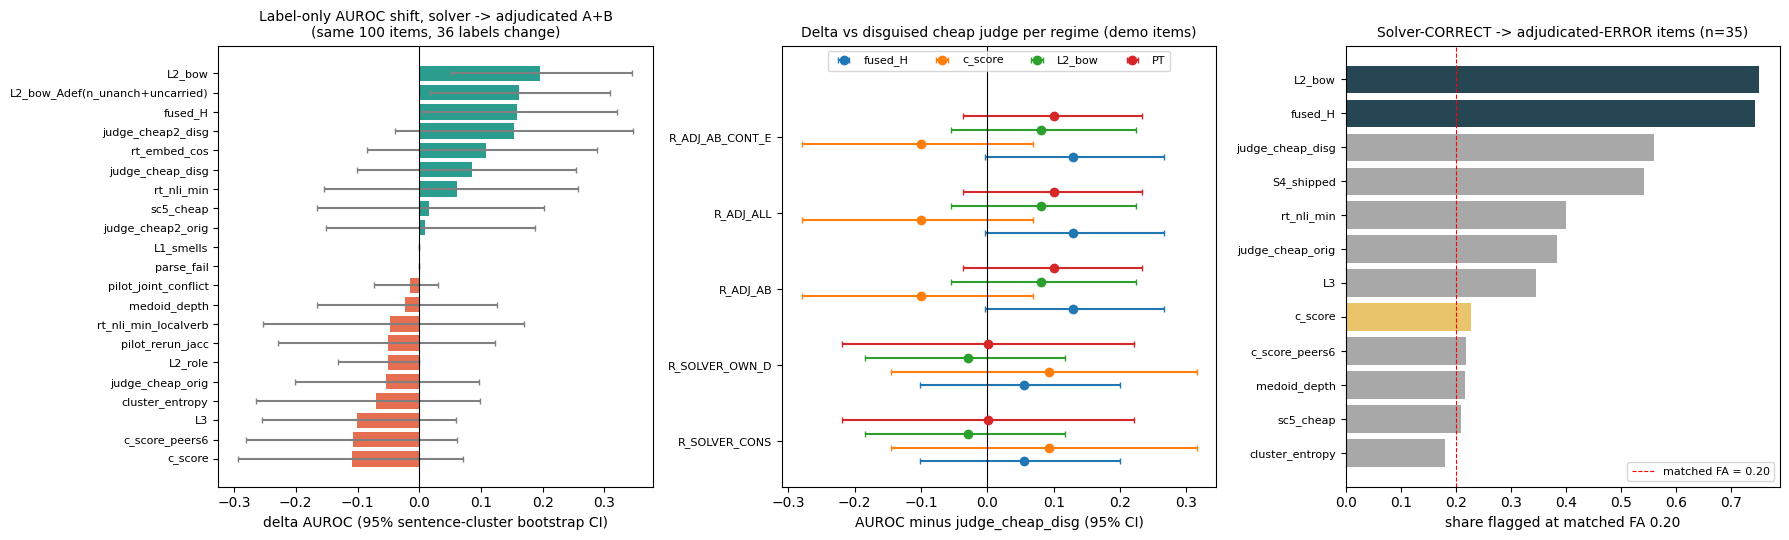

Kendall tau-b of metric rankings (selected pairs):


,regime_1,regime_2,kendall_tau_b,ci_lo,ci_hi,n_metrics
2,R_SOLVER_CONS,R_SOLVER_OWN_D,1.000,1.000,1.000,21
3,R_SOLVER_CONS,R_ADJ_AB,0.412,0.024,0.671,21
5,R_SOLVER_CONS,R_ADJ_ALL,0.412,0.024,0.671,21


Prediction 'bow flags flipped items more than c_score': {'L2_bow_share_flagged': np.float64(0.7514285714285714), 'c_score_share_flagged': np.float64(0.22857142857142856), 'supported': True}


In [14]:
KEY = ["p_fused_H", "bow_uncarried", "l3_score", "c_score", "judge_cheap_disg", "PT_oof"]
ref = data["metadata"]["full_run_reference_common_items"]
M = r5["matrix"]
rows = []
for m in KEY:
    rows.append({"metric": nice(m),
                 "AUROC demo solver (R_SOLVER_CONS)": M.loc[m, "R_SOLVER_CONS"], "AUROC demo adjudicated (R_ADJ_AB)": M.loc[m, "R_ADJ_AB"],
                 "demo shift": M.loc[m, "R_ADJ_AB"] - M.loc[m, "R_SOLVER_CONS"],
                 "full-run solver": ref["R_SOLVER_CONS"].get(m, {}).get("auroc"), "full-run A+B": ref["R_ADJ_AB"].get(m, {}).get("auroc")})
summary = pd.DataFrame(rows)
print(f"Demo common sets: R_SOLVER_CONS n={decl['R_SOLVER_CONS']['common_set']['n']} (err {decl['R_SOLVER_CONS']['common_set']['n_err']}), "
      f"R_ADJ_AB n={decl['R_ADJ_AB']['common_set']['n']} (err {decl['R_ADJ_AB']['common_set']['n_err']}); "
      f"full run: n={ref['R_SOLVER_CONS']['_n']} / {ref['R_ADJ_AB']['_n']}")
display(summary.round(3))

sh = r5["shift"]
sh = sh[(sh["from"] == "R_SOLVER_CONS") & (sh["to"] == "R_ADJ_AB")].set_index("metric")
print("\nLabel-only shift R_SOLVER_CONS -> R_ADJ_AB (same items, only labels change):")
display(sh[["n_shared", "n_label_changes", "label_only_shift", "label_only_ci_lo", "label_only_ci_hi", "direction"]].round(3))

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
# (1) label-only shift
s = sh.sort_values("label_only_shift")
ax = axes[0]
colors = ["#2a9d8f" if v > 0 else "#e76f51" for v in s.label_only_shift]
ax.barh(s.index, s.label_only_shift, color=colors,
        xerr=[s.label_only_shift - s.label_only_ci_lo, s.label_only_ci_hi - s.label_only_shift], capsize=2, ecolor="grey")
ax.axvline(0, color="k", lw=0.8)
ax.set_title(f"Label-only AUROC shift, solver -> adjudicated A+B\n(same {int(s.n_shared.iloc[0])} items, {int(s.n_label_changes.iloc[0])} labels change)", fontsize=10)
ax.set_xlabel("delta AUROC (95% sentence-cluster bootstrap CI)")
ax.tick_params(axis="y", labelsize=8)
# (2) delta vs judge per regime
ax = axes[1]
regs = [r for r in ("R_SOLVER_CONS", "R_SOLVER_OWN_D", "R_ADJ_AB", "R_ADJ_ALL", "R_ADJ_AB_CONT_E") if r in common_out]
cands = ["p_fused_H", "c_score", "bow_uncarried", "PT_oof"]
for j, c in enumerate(cands):
    for i, rn in enumerate(regs):
        t = common_out[rn]["table"]
        r = t[(t.col == c) & (t.item_set == "COMMON")]
        if not len(r):
            continue
        r = r.iloc[0]
        yv = i + (j - 1.5) * 0.18
        ax.errorbar(r.delta_vs_judge, yv, xerr=[[r.delta_vs_judge - r.delta_ci_lo], [r.delta_ci_hi - r.delta_vs_judge]],
                    fmt="o", color=f"C{j}", label=nice(c) if i == 0 else None, capsize=2)
ax.axvline(0, color="k", lw=0.8)
ax.set_yticks(range(len(regs)))
ax.set_yticklabels(regs, fontsize=8)
ax.set_xlabel("AUROC minus judge_cheap_disg (95% CI)")
ax.set_title("Delta vs disguised cheap judge per regime (demo items)", fontsize=10)
ax.set_ylim(-0.6, len(regs) + 0.2)
ax.legend(fontsize=8, loc="upper center", ncol=4)
# (3) flipped items flagged
ax = axes[2]
fs = pd.Series(flip.get("D_solver_flipped_share_flagged_FA020", {})).sort_values()
ax.barh(fs.index, fs.values, color=["#264653" if k in ("L2_bow", "fused_H") else "#e9c46a" if k == "c_score" else "#a8a8a8" for k in fs.index])
ax.axvline(0.20, color="r", ls="--", lw=0.8, label="matched FA = 0.20")
ax.set_xlabel("share flagged at matched FA 0.20")
ax.set_title(f"Solver-CORRECT -> adjudicated-ERROR items (n={flip['D_solver']['n_correct_to_error']})", fontsize=10)
ax.tick_params(axis="y", labelsize=8)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Kendall tau-b of metric rankings (selected pairs):")
tt = r5["tau"]
display(tt[(tt.regime_1 == "R_SOLVER_CONS") & tt.regime_2.isin(["R_ADJ_AB", "R_ADJ_ALL", "R_SOLVER_OWN_D"])].round(3))
print("Prediction 'bow flags flipped items more than c_score':", flip.get("prediction_bow_high_cscore_low"))